# 🎭 Thumbnail-Grid Deepfake Detector — Kaggle Edition

> **How to set up this notebook:**
> 1. Go to **Settings (right panel) → Accelerator → GPU T4 x2**
> 2. Go to **Settings → Internet → On**
> 3. Under **Input** (right panel) → **Add Data** → search for one of:
>    - `hungle3401/faceforensics`  ← FF++ ⭐ recommended
>    - `reubensuju/celeb-df-v2`   ← Celeb-DF
>    - Use the DFDC competition data if you accepted its terms
> 4. Hit **Run All**

---

**Core idea:** Tile N consecutive frames into a 2D grid. A 2D CNN attending across grid cells captures both **spatial artifacts** AND **temporal inconsistencies** — no 3D CNNs or LSTMs needed.

## ⚙️ Step 0 — Environment & GPU Check

In [29]:
import os, torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — go to Settings → Accelerator → GPU T4')

# Kaggle input datasets are mounted at /kaggle/input/
print('\nAvailable input datasets:')
for d in os.listdir('/kaggle/input/datasets'):
    print(f'  /kaggle/input/{d}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Available input datasets:
  /kaggle/input/reubensuju
  /kaggle/input/hungle3401


## 📦 Step 1 — Install Dependencies

In [28]:
!pip install -q opencv-python-headless pillow tqdm
# torch & torchvision are pre-installed on Kaggle GPU images

In [60]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


## 🗂️ Step 2 — Dataset Configuration

Set `DATASET` to match the dataset you added in the right panel.

In [43]:
import shutil, json
from pathlib import Path

# ── Choose your dataset ────────────────────────────────────────
# 'ff++'     → hungle3401/faceforensics      (recommended)
# 'celeb-df' → reubensuju/celeb-df-v2
# 'dfdc'     → deepfake-detection-challenge  (competition)
DATASET = 'ff++'
DATASET= 'celeb-df'
# Kaggle dataset slugs map to /kaggle/input/<slug-last-part>/
KAGGLE_INPUT_MAP = {
    'ff++'    : '/kaggle/input/datasets/hungle3401/faceforensics',
    'celeb-df': '/kaggle/input/datasets/reubensuju/celeb-df-v2',
    'dfdc'    : '/kaggle/input/deepfake-detection-challenge',
}


RAW_DIR  = Path(KAGGLE_INPUT_MAP[DATASET])
WORK_DIR = Path('/kaggle/working/data') / DATASET
(WORK_DIR / 'real').mkdir(parents=True, exist_ok=True)
(WORK_DIR / 'fake').mkdir(parents=True, exist_ok=True)

print(f'Dataset  : {DATASET}')
print(f'Raw path : {RAW_DIR}')
print(f'Work dir : {WORK_DIR}')
print(f'Raw dir exists: {RAW_DIR.exists()}')

Dataset  : celeb-df
Raw path : /kaggle/input/datasets/reubensuju/celeb-df-v2
Work dir : /kaggle/working/data/celeb-df
Raw dir exists: True


## 🔀 Step 3 — Reorganise into `real/` / `fake/`

In [45]:
def _copy(src, dst):
    """Symlink preferred (instant, no disk copy); fallback to copy."""
    if not dst.exists():
        try:
            dst.symlink_to(src.resolve())
        except Exception:
            shutil.copy2(src, dst)


""""def reorganise_ffpp(raw, work):
    real_out = work / 'real'
    fake_out = work / 'fake'
    copied_real = copied_fake = 0

    for src in raw.glob('original_sequences/youtube/c23/videos/*.mp4'):
        _copy(src, real_out / src.name)
        copied_real += 1

    for method in ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures']:
        for src in raw.glob(f'manipulated_sequences/{method}/c23/videos/*.mp4'):
            _copy(src, fake_out / f'{method}_{src.name}')
            copied_fake += 1

    return copied_real, copied_fake
"""
def reorganise_ffpp(raw, work):
    real_out = work / 'real'
    fake_out = work / 'fake'
    copied_real = copied_fake = 0

    # Look for videos directly in real/ folder
    for src in (raw / 'real').glob('*.mp4'):
        _copy(src, real_out / src.name)
        copied_real += 1

    # Look for videos directly in fake/ folder
    for src in (raw / 'fake').glob('*.mp4'):
        _copy(src, fake_out / src.name)
        copied_fake += 1

    return copied_real, copied_fake

def reorganise_celebdf(raw, work):
    real_out = work / 'real'
    fake_out = work / 'fake'
    copied_real = copied_fake = 0

    for folder, out in [('Celeb-real', real_out), ('YouTube-real', real_out), ('Celeb-synthesis', fake_out)]:
        for src in (raw / folder).glob('*.mp4'):
            _copy(src, out / f'{folder}_{src.name}')
            if out == real_out: copied_real += 1
            else:               copied_fake += 1

    return copied_real, copied_fake


def reorganise_dfdc(raw, work):
    real_out = work / 'real'
    fake_out = work / 'fake'
    copied_real = copied_fake = 0

    meta_path = None
    for p in raw.rglob('metadata.json'):
        meta_path = p; break
    if meta_path is None:
        raise FileNotFoundError('metadata.json not found in DFDC folder')

    with open(meta_path) as f:
        meta = json.load(f)

    video_dir = meta_path.parent
    for fname, info in meta.items():
        src = video_dir / fname
        if not src.exists(): continue
        label = info.get('label', '').upper()
        if label == 'REAL':
            _copy(src, real_out / src.name); copied_real += 1
        else:
            _copy(src, fake_out / src.name); copied_fake += 1

    return copied_real, copied_fake


# ── Run reorganisation ─────────────────────────────────────────
fn = {'ff++': reorganise_ffpp, 'celeb-df': reorganise_celebdf, 'dfdc': reorganise_dfdc}[DATASET]
n_real, n_fake = fn(RAW_DIR, WORK_DIR)

print(f'✓ Reorganised — {n_real} real | {n_fake} fake videos')
print(f'  real/ : {len(list((WORK_DIR/"real").glob("*.mp4")))} files')
print(f'  fake/ : {len(list((WORK_DIR/"fake").glob("*.mp4")))} files')

✓ Reorganised — 890 real | 5639 fake videos
  real/ : 890 files
  fake/ : 5639 files


## 🧠 Step 4 — Core Library

In [62]:
import cv2
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader


# ── Frame Extraction ──────────────────────────────────────────
def extract_frames(video_path, num_frames=8, face_size=112):
    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        raise ValueError(f'Cannot read: {video_path}')
    frames = []
    for idx in np.linspace(0, total - 1, num_frames, dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok: continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (face_size, face_size))
        frames.append(frame)
    cap.release()
    return frames


# ── Thumbnail Grid ────────────────────────────────────────────
def build_thumbnail_grid(frames, grid_rows=2):
    grid_cols = int(np.ceil(len(frames) / grid_rows))
    while len(frames) < grid_rows * grid_cols:
        frames.append(np.zeros_like(frames[0]))
    rows = []
    for r in range(grid_rows):
        row = frames[r * grid_cols: (r + 1) * grid_cols]
        rows.append(np.concatenate(row, axis=1))
    return Image.fromarray(np.concatenate(rows, axis=0))


def apply_fixed_mask(grid, mask_ratio=0.08):
    arr    = np.array(grid)
    mh, mw = int(arr.shape[0] * mask_ratio), int(arr.shape[1] * mask_ratio)
    arr[:mh, :mw] = 0
    return Image.fromarray(arr)


# ── Dataset ───────────────────────────────────────────────────
class DeepfakeVideoDataset(Dataset):
    def __init__(self, data_dir, num_frames=8, grid_rows=2,
                 face_size=112, augment=True, max_videos=None):
        self.num_frames = num_frames
        self.grid_rows  = grid_rows
        self.face_size  = face_size
        self.samples    = []

        root = Path(data_dir)
        for label, folder in [(0, 'real'), (1, 'fake')]:
            vids = sorted((root / folder).glob('*.mp4'))
            self.samples += [(v, label) for v in vids]

        if max_videos:
            real = [(p, l) for p, l in self.samples if l == 0][:max_videos // 2]
            fake = [(p, l) for p, l in self.samples if l == 1][:max_videos // 2]
            self.samples = real + fake

        grid_cols = int(np.ceil(num_frames / grid_rows))
        aug_ops   = [
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            transforms.RandomGrayscale(p=0.05),
        ] if augment else []
        self.transform = transforms.Compose(aug_ops + [
            transforms.Resize((grid_rows * face_size, grid_cols * face_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225]),
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            frames = extract_frames(str(path), self.num_frames, self.face_size)
            if len(frames) < 2: raise ValueError('too few frames')
            grid = build_thumbnail_grid(frames, self.grid_rows)
            grid = apply_fixed_mask(grid)
            return self.transform(grid), label
        except Exception:
            grid_cols = int(np.ceil(self.num_frames / self.grid_rows))
            blank = torch.zeros(3, self.face_size * self.grid_rows,
                                   self.face_size * grid_cols)
            return blank, label


# ── Model ─────────────────────────────────────────────────────
"""class ThumbnailDeepfakeDetector(nn.Module):
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()
        weights       = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        bb            = models.efficientnet_b0(weights=weights)
        self.features = bb.features
        self.avgpool  = bb.avgpool
        in_feats      = bb.classifier[1].in_features
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_feats, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)
"""
import timm # Import timm for Xception support

class ThumbnailDeepfakeDetector(nn.Module):
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()
        # Load Xception model from timm
        # 'xception' is the original version, 'xception41' or 'xception71' are also available
        self.bb = timm.create_model('xception', pretrained=pretrained)
        
        # In timm's Xception, the 'fc' is the final linear layer. 
        # We capture the input features of that layer (usually 2048)
        in_feats = self.bb.fc.in_features
        
        # Remove the original classifier so we can use our custom head
        self.bb.fc = nn.Identity() 

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_feats, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        # timm models usually have a forward_features method 
        # but calling the model directly with fc=Identity works perfectly
        x = self.bb(x) 
        # Xception features are already pooled in this setup
        return self.classifier(x)

print('✓ Core library ready')

✓ Core library ready


## 🖼️ Step 5 — Sanity Check: Visualize a Thumbnail Grid

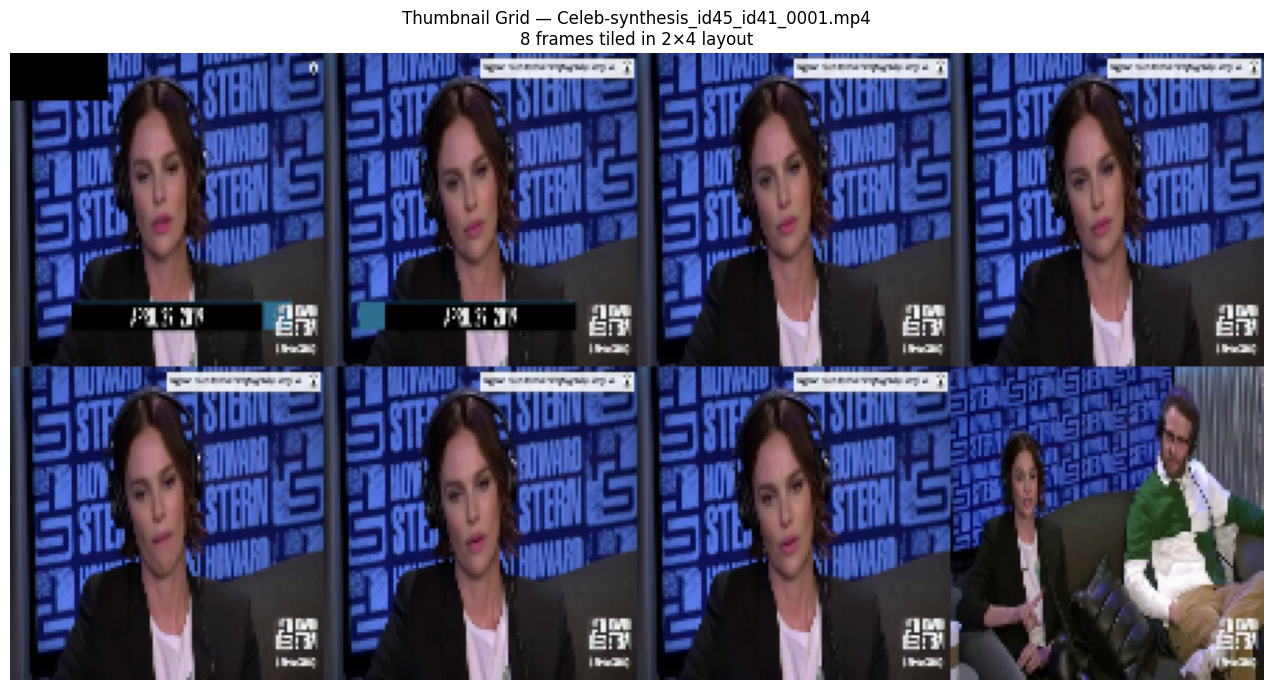

Grid size: 448×224 px


In [63]:
import matplotlib.pyplot as plt

sample = next((WORK_DIR / 'fake').glob('*.mp4'), None) or \
         next((WORK_DIR / 'real').glob('*.mp4'), None)

if sample:
    frames = extract_frames(str(sample), num_frames=8, face_size=112)
    grid   = build_thumbnail_grid(frames, grid_rows=2)
    grid   = apply_fixed_mask(grid)

    plt.figure(figsize=(14, 7))
    plt.imshow(grid)
    plt.axis('off')
    plt.title(f'Thumbnail Grid — {sample.name}\n'
              f'{len(frames)} frames tiled in 2×4 layout', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'Grid size: {grid.size[0]}×{grid.size[1]} px')
else:
    print('No video found — check Step 3.')

## 🏋️ Step 6 — Training Configuration

In [64]:
# ── Hyperparameters ────────────────────────────────────────────
TRAIN_DATA  = str(WORK_DIR)
EPOCHS      = 10
BATCH_SIZE  = 16         # T4 x2 can handle 16 comfortably
LR          = 2e-4
SAVE_PATH   = '/kaggle/working/detector.pth'
VAL_SPLIT   = 0.2
MAX_VIDEOS  = 400        # set None to use entire dataset
NUM_WORKERS = 4          # Kaggle gives 4 CPU cores

print(f'Training on : {TRAIN_DATA}')
print(f'Max videos  : {MAX_VIDEOS or "all"}')
print(f'Epochs      : {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')
print(f'Checkpoint  : {SAVE_PATH}')

Training on : /kaggle/working/data/celeb-df
Max videos  : 400
Epochs      : 10 | Batch: 16 | LR: 0.0002
Checkpoint  : /kaggle/working/detector.pth


## 🚀 Step 7 — Train

In [65]:
def _approx_auc(labels, probs):
    pairs = sorted(zip(probs, labels), reverse=True)
    tp = fp = auc = prev_fpr = prev_tpr = 0.0
    pos = sum(labels) or 1
    neg = len(labels) - pos or 1
    for _, label in pairs:
        if label == 1: tp += 1
        else:          fp += 1
        tpr, fpr = tp / pos, fp / neg
        auc += (fpr - prev_fpr) * (tpr + prev_tpr) / 2
        prev_fpr, prev_tpr = fpr, tpr
    return auc


# ── Prepare data ──────────────────────────────────────────────
full_ds = DeepfakeVideoDataset(TRAIN_DATA, augment=False, max_videos=MAX_VIDEOS)
n_val   = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {n_train} | Val: {n_val}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ── Model / optimizer ─────────────────────────────────────────
model     = ThumbnailDeepfakeDetector(pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
best_auc  = 0.0

train_losses, val_losses, val_aucs = [], [], []

# ── Training loop ──────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    t_loss = 0.0
    for grids, labels in tqdm(train_loader, desc=f'[{epoch}/{EPOCHS}] Train'):
        grids  = grids.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        loss = criterion(model(grids), labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    # Validate
    model.eval()
    v_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels  = [], []
    with torch.no_grad():
        for grids, labels in tqdm(val_loader, desc=f'[{epoch}/{EPOCHS}] Val  '):
            grids  = grids.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            logits = model(grids)
            v_loss += criterion(logits, labels).item()
            probs   = torch.sigmoid(logits).cpu()
            correct += ((probs > 0.5).float() == labels.cpu()).sum().item()
            total   += labels.size(0)
            all_probs.extend(probs.squeeze().tolist())
            all_labels.extend(labels.cpu().squeeze().tolist())

    auc    = _approx_auc(all_labels, all_probs)
    tl_avg = t_loss / len(train_loader)
    vl_avg = v_loss / len(val_loader)
    acc    = 100 * correct / max(total, 1)
    train_losses.append(tl_avg)
    val_losses.append(vl_avg)
    val_aucs.append(auc)

    print(f'  Epoch {epoch:02d} | train_loss={tl_avg:.4f} | '
          f'val_loss={vl_avg:.4f} | acc={acc:.1f}% | AUC≈{auc:.3f}')

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  ✓ Best model saved (AUC={auc:.3f}) → {SAVE_PATH}')

    scheduler.step()

print(f'\n🏆 Training complete — Best AUC: {best_auc:.3f}')

Train: 320 | Val: 80


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


[1/10] Train:   0%|          | 0/20 [00:00<?, ?it/s]

[1/10] Val  :   0%|          | 0/5 [00:00<?, ?it/s]

...

[9/10] Val  :   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 09 | train_loss=0.2658 | val_loss=0.9331 | acc=75.0% | AUC≈0.771


[10/10] Train:   0%|          | 0/20 [00:00<?, ?it/s]

[10/10] Val  :   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 10 | train_loss=0.2585 | val_loss=0.9495 | acc=75.0% | AUC≈0.765

🏆 Training complete — Best AUC: 0.820


## 📊 Step 8 — Training Curves

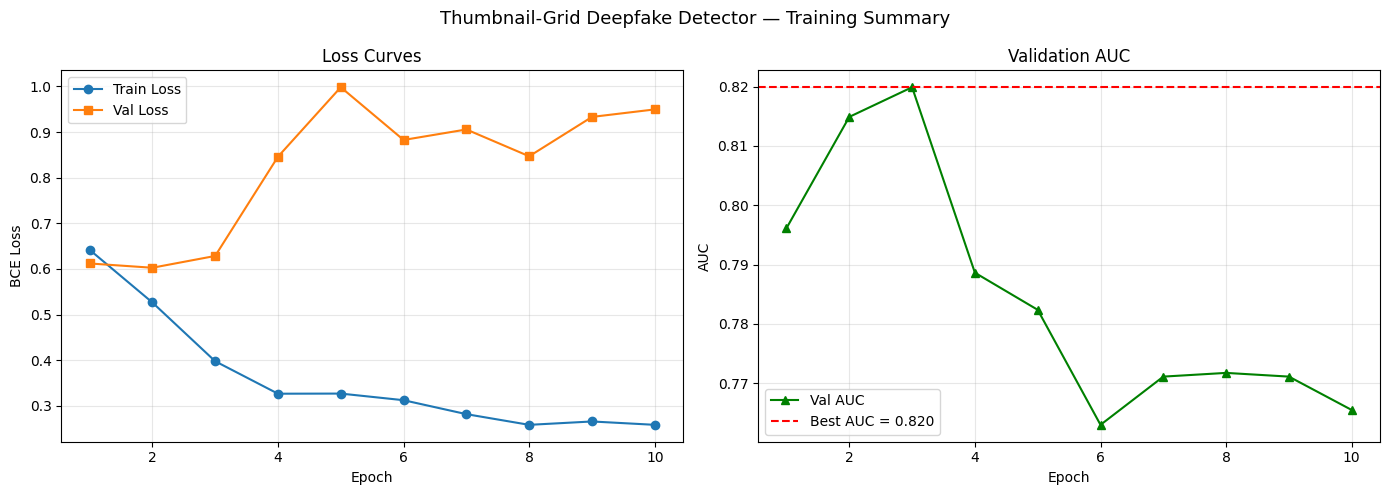

Saved → /kaggle/working/training_curves.png


In [66]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, label='Train Loss', marker='o')
ax1.plot(epochs_range, val_losses,   label='Val Loss',   marker='s')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, val_aucs, label='Val AUC', marker='^', color='green')
ax2.axhline(y=best_auc, color='red', linestyle='--',
            label=f'Best AUC = {best_auc:.3f}')
ax2.set_title('Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Thumbnail-Grid Deepfake Detector — Training Summary', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/training_curves.png')

## 🔍 Step 9 — Inference

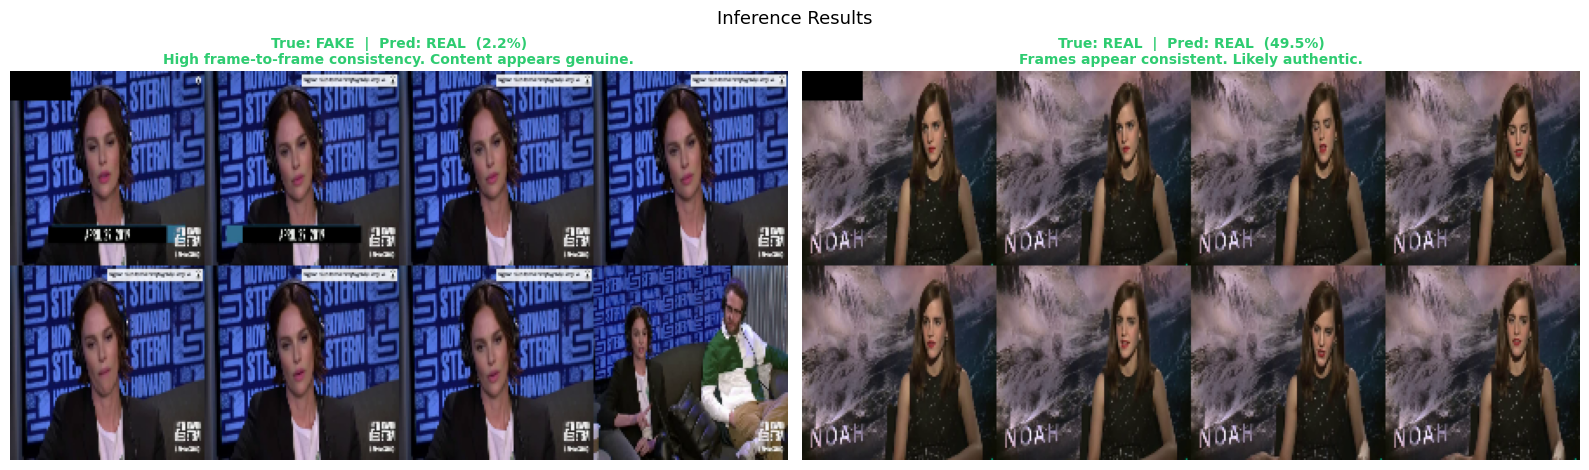

In [67]:
def predict(video_path, model_path=SAVE_PATH,
            num_frames=8, grid_rows=2, face_size=112):
    grid_cols = int(np.ceil(num_frames / grid_rows))
    transform = transforms.Compose([
        transforms.Resize((grid_rows * face_size, grid_cols * face_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    m = ThumbnailDeepfakeDetector(pretrained=False)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval().to(device)

    frames    = extract_frames(video_path, num_frames, face_size)
    grid      = build_thumbnail_grid(frames, grid_rows)
    grid      = apply_fixed_mask(grid)
    tensor    = transform(grid).unsqueeze(0).to(device)

    with torch.no_grad():
        prob_fake = torch.sigmoid(m(tensor)).item()

    label = 'FAKE' if prob_fake > 0.5 else 'REAL'
    if   prob_fake > 0.85: exp = 'Strong temporal inconsistencies across frames.'
    elif prob_fake > 0.65: exp = 'Subtle spatial artifacts in face region over time.'
    elif prob_fake > 0.50: exp = 'Minor inconsistencies — borderline, low confidence.'
    elif prob_fake > 0.30: exp = 'Frames appear consistent. Likely authentic.'
    else:                  exp = 'High frame-to-frame consistency. Content appears genuine.'

    return dict(label=label, confidence=round(prob_fake, 4),
                score=round(prob_fake * 100, 1), explanation=exp,
                frames_used=len(frames), grid_shape=f'{grid_rows}×{grid_cols}')


# ── Run on a sample video ─────────────────────────────────────
test_fake = next((WORK_DIR / 'fake').glob('*.mp4'), None)
test_real = next((WORK_DIR / 'real').glob('*.mp4'), None)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, vid, true_label in zip(axes,
                                [test_fake, test_real],
                                ['FAKE', 'REAL']):
    if vid is None:
        ax.axis('off'); continue

    res    = predict(str(vid))
    frames = extract_frames(str(vid))
    grid   = build_thumbnail_grid(frames)
    grid   = apply_fixed_mask(grid)

    ax.imshow(grid)
    ax.axis('off')
    color = '#e74c3c' if res['label'] == 'FAKE' else '#2ecc71'
    ax.set_title(
        f'True: {true_label}  |  Pred: {res["label"]}  ({res["score"]}%)\n'
        f'{res["explanation"]}',
        color=color, fontsize=10, fontweight='bold'
    )

plt.suptitle('Inference Results', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/inference_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 📤 Step 10 — Save Outputs

Everything saved under `/kaggle/working/` is automatically kept when you **Save & Run All**.
You can also version the notebook to publish results on Kaggle.

In [ ]:
import os

outputs = [
    '/kaggle/working/detector.pth',
    '/kaggle/working/training_curves.png',
    '/kaggle/working/inference_results.png',
]

print('📁 Output files:')
for f in outputs:
    size = os.path.getsize(f) / 1e6 if os.path.exists(f) else 0
    status = f'{size:.2f} MB' if size else 'NOT FOUND'
    print(f'  {f}  →  {status}')

print('\n✅ Done! Use "Save & Run All" then check the Output tab to access files.')